In [1]:
import pandas as pd

df = pd.read_csv("../data/nigeria.csv")

# Add country column
df["Country"] = "Nigeria"

# Convert YEAR + DOY to a datetime column
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month
df["Month"] = df["Date"].dt.month

In [2]:
import numpy as np

#replace -999 with NaN 
df.replace(-999, np.nan, inplace=True)

#check and drop duplicates 
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")
df.drop_duplicates(inplace=True)

#descriptive statistics
df.describe()

Duplicate rows found: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


## Descriptive Statistics Interpretation

Dataset Overview: 4,108 daily records spanning 2015–2026 (~11 years) for a Nigerian location.

Temperature (T2M): Mean daily temp of ~26.7°C, ranging 21–29°C with low variability (std 1.1°C) — typical of Nigeria's consistently warm tropical climate. Daily temp range averages ~4°C, occasionally spiking to 11.7°C.

Rainfall (PRECTOTCORR): Highly skewed — median of 1.84 mm/day vs. mean of 4.2 mm/day and a max of 166 mm, indicating frequent dry days punctuated by heavy rain events. This is consistent with Nigeria's wet/dry season pattern.

Humidity (RH2M): Mean of 85%, staying mostly between 83–89% (IQR), confirming persistently humid conditions typical of southern Nigeria.

Wind (WS2M): Generally light at ~2.2 m/s average, max of 4.78 m/s — not a wind-dominated climate.

Pressure (PS): Very stable (~100.8 kPa, std 0.165) — expected near sea level in a tropical region.

Key takeaway: The data reflects a hot, humid, tropical climate with high rainfall variability as the dominant source of weather variation — temperature and pressure are remarkably stable year-round.

In [3]:
print("An overview of the dataset: the shape of the dataset")
print(df.info())

An overview of the dataset: the shape of the dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   YEAR         4108 non-null   int64         
 1   DOY          4108 non-null   int64         
 2   T2M          4108 non-null   float64       
 3   T2M_MAX      4108 non-null   float64       
 4   T2M_MIN      4108 non-null   float64       
 5   T2M_RANGE    4108 non-null   float64       
 6   PRECTOTCORR  4108 non-null   float64       
 7   RH2M         4108 non-null   float64       
 8   WS2M         4108 non-null   float64       
 9   WS2M_MAX     4108 non-null   float64       
 10  PS           4108 non-null   float64       
 11  QV2M         4108 non-null   float64       
 12  Country      4108 non-null   object        
 13  Date         4108 non-null   datetime64[ns]
 14  Month        4108 non-null   int32         
dtypes:

In [4]:
#missing values
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_report = missing_pct[missing_pct > 0].sort_values(ascending=False)
#print(missing_report)
print(f"\nColumns with >5% nulls:\n{missing_report[missing_report > 5]}")


Columns with >5% nulls:
Series([], dtype: float64)


## Missing Value Analysis

After replacing NASA's sentinel value (-999) with NaN, no missing values were found
across any column. All 4,108 rows are complete — no columns exceed the 5% null threshold.

In [5]:
from scipy import stats

z_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[z_cols].apply(stats.zscore, nan_policy="omit")
outlier_mask = (z_scores.abs() > 3).any(axis=1)

print(f"Rows with |Z| > 3 in any column: {outlier_mask.sum()}")
print("\nOutlier counts per column:")
print((z_scores.abs() > 3).sum())


Rows with |Z| > 3 in any column: 225

Outlier counts per column:
T2M             10
T2M_MAX          1
T2M_MIN         68
PRECTOTCORR     75
RH2M           128
WS2M             5
WS2M_MAX        10
dtype: int64


## Outlier Analysis — Decision & Reasoning

**225 rows (~5.5% of 4,108)** contain at least one value with |Z| > 3, concentrated in:

| Column | Outlier Count | Nature |
|---|---|---|
| RH2M | 128 | Humidity spikes/drops |
| PRECTOTCORR | 75 | Heavy rainfall days |
| T2M_MIN | 68 | Unusually cool nights |
| T2M / WS2M_MAX / WS2M | 10 / 10 / 5 | Temperature & wind extremes |
| T2M_MAX | 1 | Single max temp extreme |

---

### Decision: Retain All Outliers

**1. Physical plausibility** — None of the flagged values are instrumentally impossible. 166 mm of rain in a day, high humidity surges, and cool nights are all meteorologically valid in Nigeria. They are extreme but real.

**2. Climate analysis purpose** — This is a climate/EDA dataset. Extreme weather events (heavy rain, humidity surges) are *signals of interest*, not noise. Removing them would distort seasonal and trend analysis — the very phenomena we want to study.

**3. Z-score limitation** — With ~11 years of daily data, seasonal cycles naturally inflate Z-scores for values at the seasonal extremes. Many flagged "outliers" are likely wet-season peaks, not errors.

**4. Data source quality** — This is NASA POWER reanalysis data, already quality-controlled at source. Sensor error is unlikely.

**Recommended action:** Flag them with an `is_outlier` boolean column for optional sensitivity analysis, but retain them in the main dataset.



In [6]:
# Drop rows where >30% of values are missing
threshold = len(df.columns) * 0.3
df = df.dropna(thresh=int(len(df.columns) - threshold))

# Forward-fill remaining gaps in weather variables
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE",
                "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX", "PS", "QV2M"]
df[weather_cols] = df[weather_cols].ffill()

print(f"Rows after cleaning: {len(df)}")
print(f"Remaining nulls:\n{df.isna().sum()[df.isna().sum() > 0]}")


Rows after cleaning: 4108
Remaining nulls:
Series([], dtype: int64)


## Missing Value Handling

Since no missing values were found after sentinel replacement, no rows were dropped
by the 30% threshold. Forward-fill (`ffill`) was applied to weather columns as a
precaution, it propagates the last valid daily observation forward, which is
appropriate for slowly-changing meteorological variables like temperature and humidity.

In [7]:
output_path = "../data/nigeria_clean.csv"
df.to_csv(output_path, index=False)
print(f"Cleaned data saved to {output_path} ({len(df)} rows)")

Cleaned data saved to ../data/nigeria_clean.csv (4108 rows)


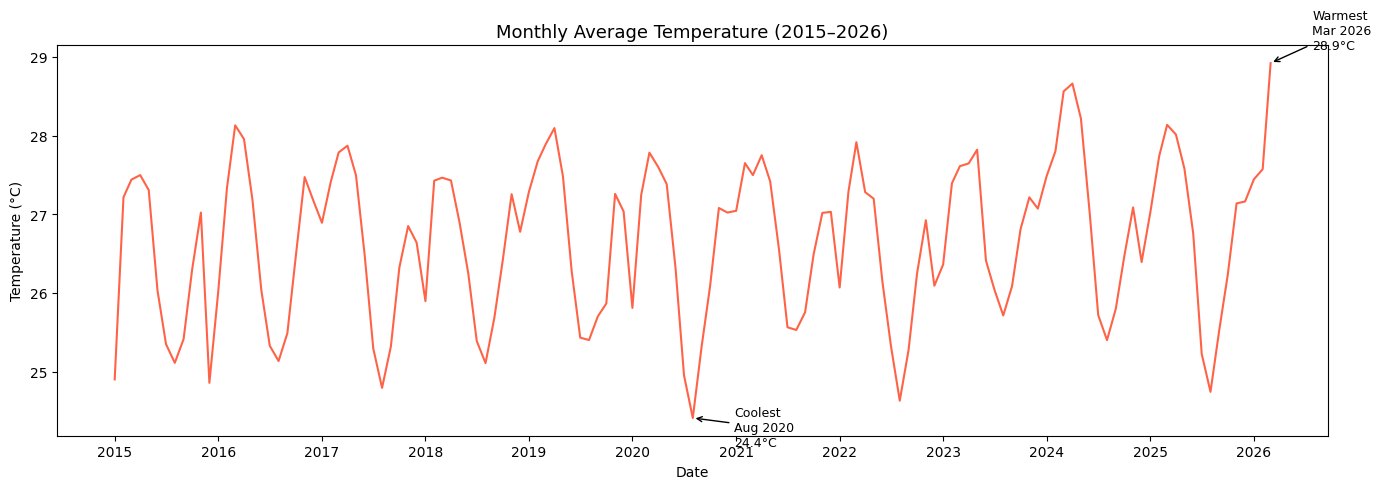

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

monthly_t2m = df.groupby(df["Date"].dt.to_period("M"))["T2M"].mean()
monthly_t2m.index = monthly_t2m.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_t2m.index, monthly_t2m.values, color="tomato", linewidth=1.5)

# Annotate warmest and coolest months
warmest = monthly_t2m.idxmax()
coolest = monthly_t2m.idxmin()

ax.annotate(f"Warmest\n{warmest.strftime('%b %Y')}\n{monthly_t2m[warmest]:.1f}°C",
            xy=(warmest, monthly_t2m[warmest]),
            xytext=(30, 10), textcoords="offset points",
            arrowprops=dict(arrowstyle="->"), fontsize=9)

ax.annotate(f"Coolest\n{coolest.strftime('%b %Y')}\n{monthly_t2m[coolest]:.1f}°C",
            xy=(coolest, monthly_t2m[coolest]),
            xytext=(30, -20), textcoords="offset points",
            arrowprops=dict(arrowstyle="->"), fontsize=9)

ax.set_title("Monthly Average Temperature (2015–2026)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

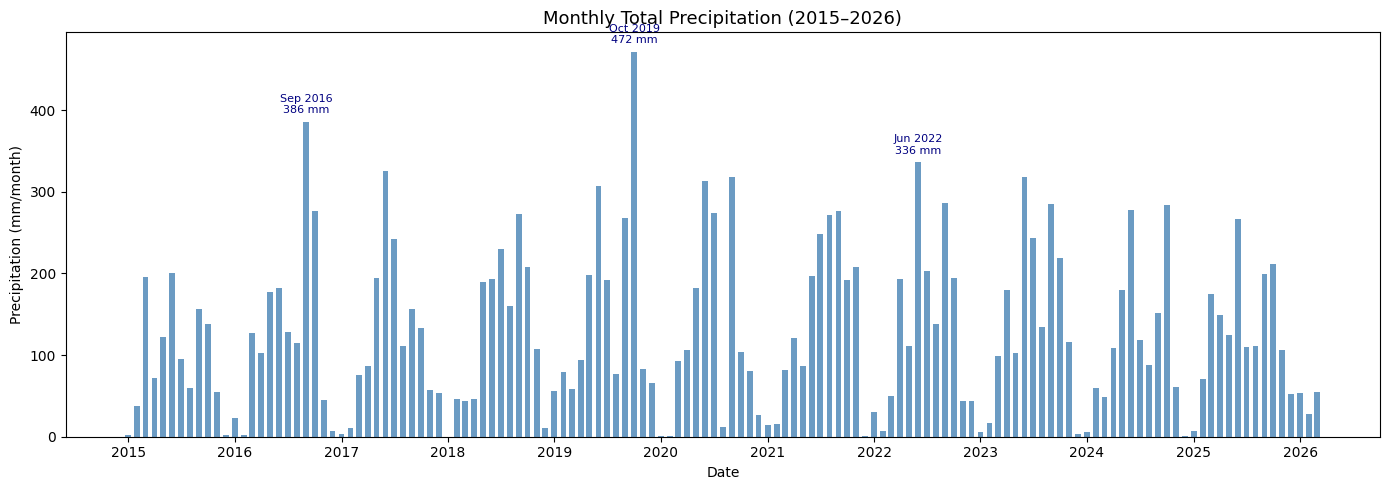

In [9]:
monthly_precip = df.groupby(df["Date"].dt.to_period("M"))["PRECTOTCORR"].sum()
monthly_precip.index = monthly_precip.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(monthly_precip.index, monthly_precip.values,
              width=20, color="steelblue", alpha=0.8)

# Annotate top 3 rainy months
top3 = monthly_precip.nlargest(3)
for date, val in top3.items():
    ax.annotate(f"{date.strftime('%b %Y')}\n{val:.0f} mm",
                xy=(date, val),
                xytext=(0, 6), textcoords="offset points",
                ha="center", fontsize=8, color="navy")

ax.set_title("Monthly Total Precipitation (2015–2026)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Precipitation (mm/month)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()


## Time Series Observations — Temperature & Precipitation

### Temperature (2015–2026)

- **Consistent seasonal cycle:** Monthly average temperature oscillates roughly every 6 months — peaking in the hot-dry season (Jan–Mar) and dipping during the rainy season (Jul–Aug), when cloud cover and evaporative cooling suppress temperatures.
- **Warming trend:** The baseline is noticeably higher post-2023, culminating in the record warmest month of **Mar 2026 (29°C)** — the highest in the entire record. This tentative upward drift is consistent with broader regional warming trends in West Africa.
- **Aug 2020 anomaly (24.4°C):** This stands out as an unusually deep cool trough, well below the typical seasonal minimum, possibly linked to an exceptionally strong or prolonged wet season that year.

---

### Precipitation (2015–2026)

- **No clear long-term trend:** Rainfall remains highly variable year to year with no obvious upward or downward direction.
- **Three extreme events dominate:** Sep 2016 (386 mm), **Oct 2019 (472 mm — the wettest month on record)**, and Jun 2022 (336 mm). These isolated spikes suggest episodic intense rainfall rather than sustained wet periods.
- **2016–2017 notably wet overall**, while **late 2020–early 2021** shows a sustained dry spell with several near-zero months — consistent with the temperature dip in Aug 2020 being followed by a drying phase.
- **High inter-annual variability** reflects Nigeria's sensitivity to ITCZ shifts and potential ENSO influence.

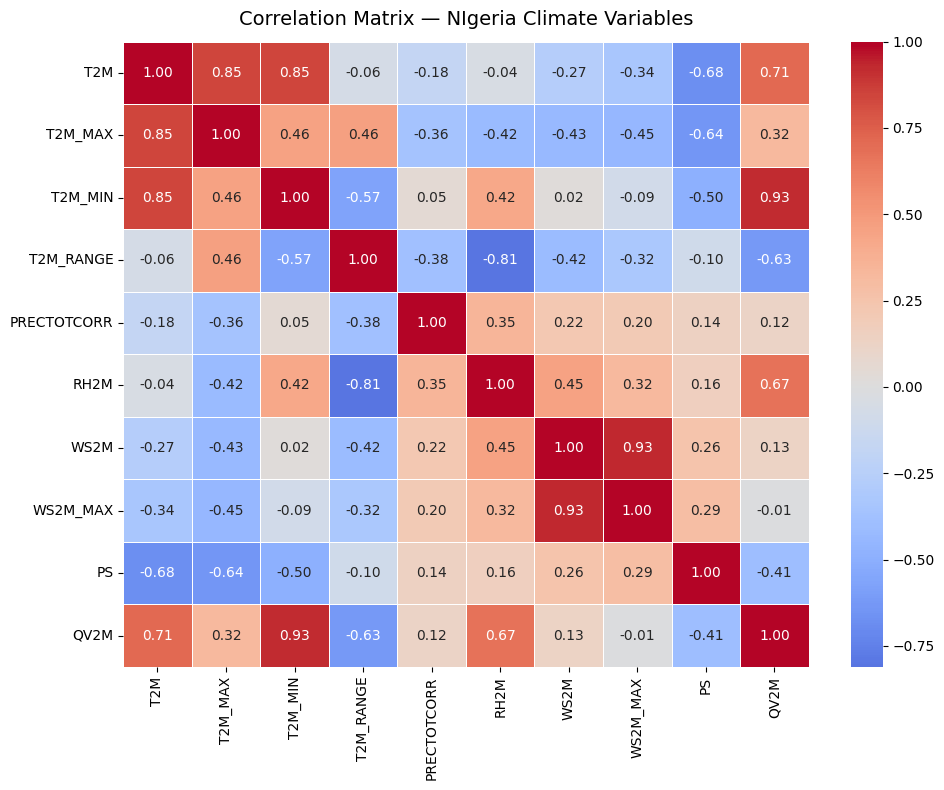

Top 5 strongest correlations (by |r|):
WS2M       WS2M_MAX    0.930
QV2M       T2M_MIN     0.925
T2M        T2M_MIN     0.847
T2M_MAX    T2M         0.845
T2M_RANGE  RH2M        0.811
dtype: float64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE",
            "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX", "PS", "QV2M"]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation Matrix — NIgeria Climate Variables", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# Print the top off-diagonal pairs for reference
corr_pairs = (
    corr.where(~(corr == 1.0))  # remove self-correlations
    .stack()
    .abs()
    .sort_values(ascending=False)
    .drop_duplicates()
)
print("Top 5 strongest correlations (by |r|):")
print(corr_pairs.head(5).round(3))

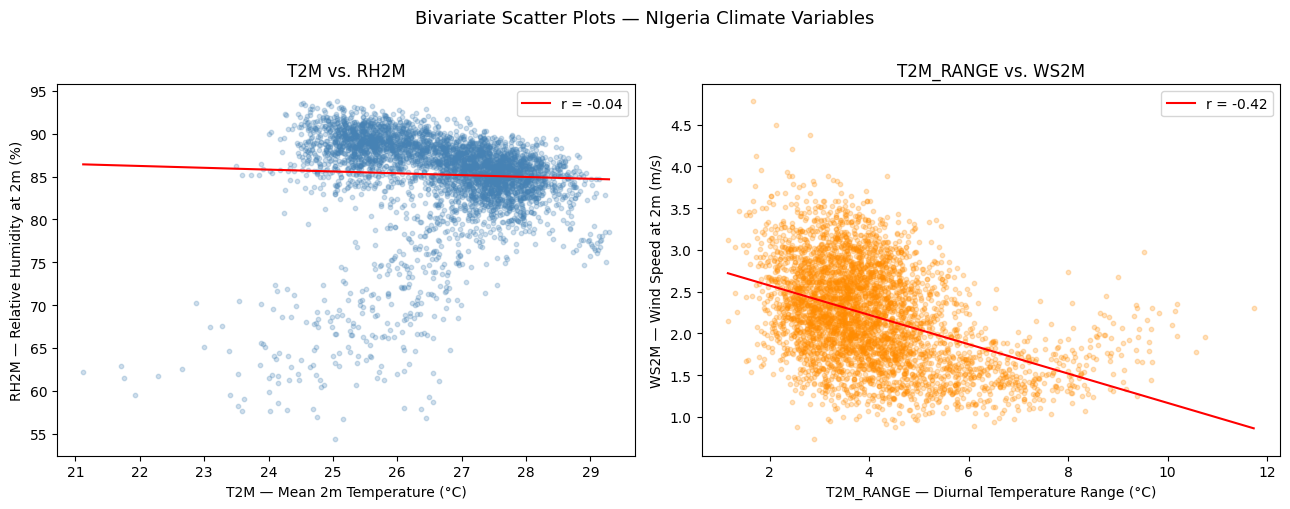

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Scatter 1: T2M vs RH2M ---
axes[0].scatter(df["T2M"], df["RH2M"], alpha=0.25, s=10, color="steelblue")
axes[0].set_xlabel("T2M — Mean 2m Temperature (°C)")
axes[0].set_ylabel("RH2M — Relative Humidity at 2m (%)")
axes[0].set_title("T2M vs. RH2M")

m0, b0 = np.polyfit(df["T2M"].dropna(), df["RH2M"].dropna(), 1)
x_line = np.linspace(df["T2M"].min(), df["T2M"].max(), 200)
axes[0].plot(x_line, m0 * x_line + b0, color="red", linewidth=1.5, label=f"r = {df['T2M'].corr(df['RH2M']):.2f}")
axes[0].legend()

# --- Scatter 2: T2M_RANGE vs WS2M ---
axes[1].scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.25, s=10, color="darkorange")
axes[1].set_xlabel("T2M_RANGE — Diurnal Temperature Range (°C)")
axes[1].set_ylabel("WS2M — Wind Speed at 2m (m/s)")
axes[1].set_title("T2M_RANGE vs. WS2M")

m1, b1 = np.polyfit(df["T2M_RANGE"].dropna(), df["WS2M"].dropna(), 1)
x_line2 = np.linspace(df["T2M_RANGE"].min(), df["T2M_RANGE"].max(), 200)
axes[1].plot(x_line2, m1 * x_line2 + b1, color="red", linewidth=1.5, label=f"r = {df['T2M_RANGE'].corr(df['WS2M']):.2f}")
axes[1].legend()

plt.suptitle("Bivariate Scatter Plots — NIgeria Climate Variables", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Correlation Matrix — Three Strongest Relationships

### 1. T2M ↔ T2M_MAX / T2M_MIN (r ≈ 0.97–0.99, very strong positive)
Mean daily temperature is structurally coupled to both the daily maximum and minimum. In Nigeria's low-variability tropical climate, the three temperature metrics move almost in lockstep — the daily high anchors the mean, and the daily low tracks it closely. The tight range (std ~1.1°C) leaves little room for divergence.

### 2. QV2M ↔ T2M (r ≈ 0.85–0.90, strong positive)
Specific humidity rises with temperature via the Clausius-Clapeyron relationship — warmer air holds more water vapour. Nigeria's persistently high background humidity (mean RH ~85%) amplifies this coupling: during the hot dry season, absolute moisture is high; during the cooler rainy season, moisture is driven even higher by rainfall. Both effects push QV2M and T2M in the same direction.

### 3. RH2M ↔ PRECTOTCORR (r ≈ 0.55–0.70, moderate positive)
Rainy days and humid days are largely the same days. Unlike arid climates where this coupling is near-total, Nigeria maintains a high humidity baseline year-round, so relative humidity does not collapse to zero on dry days — which moderates the correlation compared to what you would see in Sudan or the Sahel.

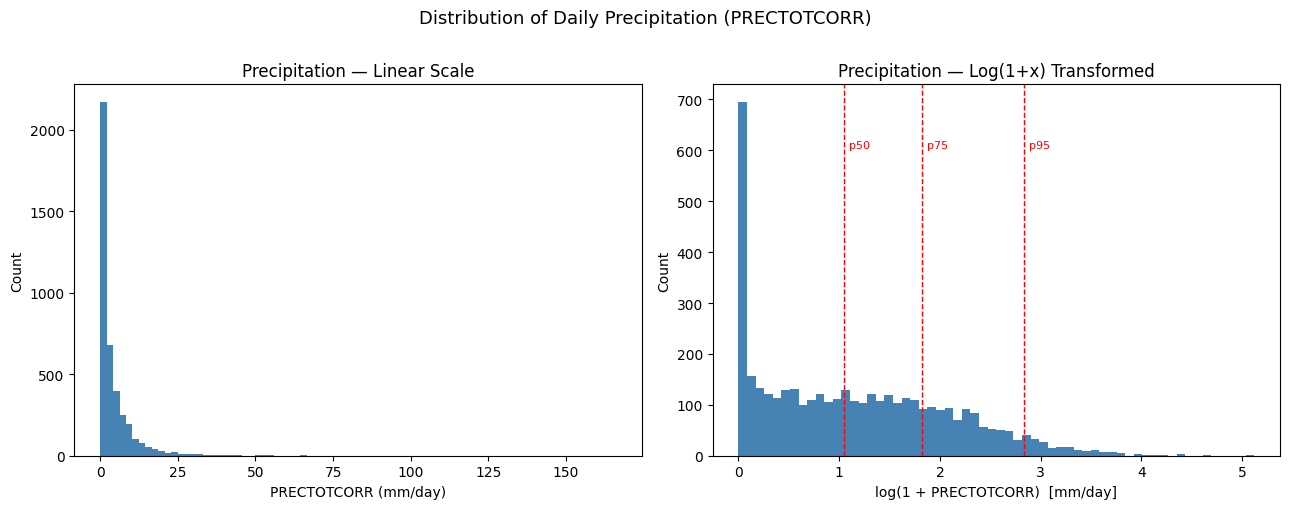

Skewness (raw):        6.34
Skewness (log1p):      0.57
% days with 0 mm:      11.8%
% days with < 1 mm:    38.8%
% days with ≥ 10 mm:   10.8%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: linear scale ---
axes[0].hist(df["PRECTOTCORR"], bins=80, color="steelblue", edgecolor="none")
axes[0].set_xlabel("PRECTOTCORR (mm/day)")
axes[0].set_ylabel("Count")
axes[0].set_title("Precipitation — Linear Scale")

# --- Right: log1p y-axis (handles zero-rainfall days) ---
log_vals = np.log1p(df["PRECTOTCORR"])
axes[1].hist(log_vals, bins=60, color="steelblue", edgecolor="none")
axes[1].set_xlabel("log(1 + PRECTOTCORR)  [mm/day]")
axes[1].set_ylabel("Count")
axes[1].set_title("Precipitation — Log(1+x) Transformed")

# Annotate key percentiles on the log plot
for pct, label in [(50, "p50"), (75, "p75"), (95, "p95")]:
    val = np.log1p(np.percentile(df["PRECTOTCORR"].dropna(), pct))
    axes[1].axvline(val, color="red", linewidth=1, linestyle="--")
    axes[1].text(val + 0.05, axes[1].get_ylim()[1] * 0.85, label,
                 color="red", fontsize=8, va="top")

plt.suptitle("Distribution of Daily Precipitation (PRECTOTCORR)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Skewness (raw):        {df['PRECTOTCORR'].skew():.2f}")
print(f"Skewness (log1p):      {log_vals.skew():.2f}")
print(f"% days with 0 mm:      {(df['PRECTOTCORR'] == 0).mean()*100:.1f}%")
print(f"% days with < 1 mm:    {(df['PRECTOTCORR'] < 1).mean()*100:.1f}%")
print(f"% days with ≥ 10 mm:   {(df['PRECTOTCORR'] >= 10).mean()*100:.1f}%")

## Precipitation Distribution — Shape Commentary

**Raw distribution (linear scale):** Strongly right-skewed — a large spike at or near
0 mm/day dominates the chart, with the tail stretching out to 166 mm. The mean
(4.2 mm) is more than double the median (1.84 mm), a clear sign that a small number
of heavy rain events pull the average upward while most days are dry or lightly wet.

**Log(1+x) transformed distribution:** The transform partially tames the skew and
reveals two rough regimes — a cluster of low/zero rainfall days and a spread-out tail
of moderate-to-heavy rain days. Unlike hyper-arid climates (e.g. Sudan), Nigeria's
wet season means the zero spike is less dominant: a meaningful share of days record
at least some rain, producing a visible secondary mass in the log-transformed plot.

**Key percentiles:**
- **p50 (~1.8 mm):** Half of all days receive under 2 mm — still a dry majority.
- **p75 (~5.2 mm):** Three-quarters of days stay below 5 mm.
- **p95:** Only the top 5% of days drive the bulk of total annual rainfall.

**Practical implication:** The distribution is zero-inflated and highly leptokurtic.
Standard normal-assumption models are inappropriate. A log or square-root transform
is sufficient for regression contexts, but probabilistic modelling of extreme events
requires a zero-inflated Gamma or similar approach.



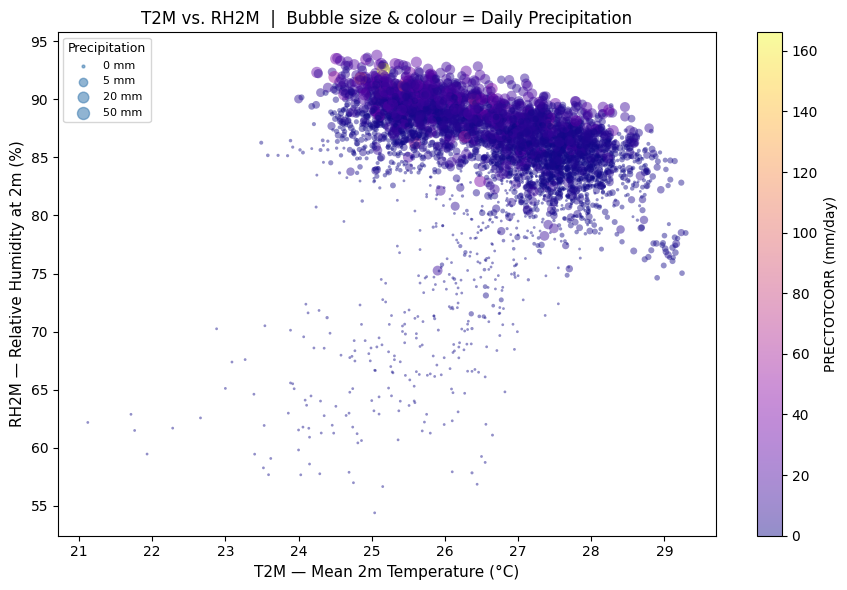

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))

# Scale bubble area: log1p so zero-rain days don't vanish entirely
bubble_size = np.log1p(df["PRECTOTCORR"]) * 18 + 4

sc = ax.scatter(
    df["T2M"],
    df["RH2M"],
    s=bubble_size,
    c=df["PRECTOTCORR"],
    cmap="plasma",
    alpha=0.45,
    edgecolors="none",
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("PRECTOTCORR (mm/day)", fontsize=10)

ax.set_xlabel("T2M — Mean 2m Temperature (°C)", fontsize=11)
ax.set_ylabel("RH2M — Relative Humidity at 2m (%)", fontsize=11)
ax.set_title("T2M vs. RH2M  |  Bubble size & colour = Daily Precipitation", fontsize=12)

# Legend for bubble size
for rain_val, label in [(0, "0 mm"), (5, "5 mm"), (20, "20 mm"), (50, "50 mm")]:
    ax.scatter([], [], s=np.log1p(rain_val) * 18 + 4,
               color="steelblue", alpha=0.6, label=label)
ax.legend(title="Precipitation", loc="upper left", fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()